# Compare CellBender vs. CellStraightener Poisson-NB Denoising

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anndata as ad
import seaborn as sns
from cellbender.remove_background.downstream import anndata_from_h5
from cellstraightener import denoise_counts_poisson_nb, denoise_counts_celltype_ambient
import cellstraightener.utils as cs_utils

cellstraightener_dir = os.path.dirname(os.path.abspath(""))

Some datasets of use:
- tiny dataset from CellBender (CellBender/examples/remove_background/generate_tiny_10x_dataset.py): https://www.10xgenomics.com/resources/datasets/10-k-heart-cells-from-an-e-18-mouse-v-3-chemistry-3-standard-3-0-0 

- 8k PBMCs from a healthy donor (CellBender Fig2): https://www.10xgenomics.com/datasets/8-k-pbm-cs-from-a-healthy-donor-2-standard-2-1-0

In [2]:
dataset_name = "tiny_cellbender"  # options: tiny_cellbender, pbmc8k, custom
threads = 16
wompwomp_path = os.path.join(os.path.dirname(cellstraightener_dir), "wompwomp")  # only needed if dataset_name == "custom"
verbose = 2  # 2 debug, 1 info, 0 warning, -1 error, -2 critical

original_matrix_custom = None  # only needed if dataset_name == "custom"
matrix_cleaned_cellbender_custom = None  # only needed if dataset_name == "custom"
matrix_cleaned_cs_poisson_custom = None  # only needed if dataset_name == "custom"
model_pkl_custom = None  # only needed if dataset_name == "custom"
cellbender_epochs_custom = None  # only needed if dataset_name == "custom"
cellbender_total_droplets_custom = None  # only needed if dataset_name == "custom"
expected_cells_custom = None  # only needed if dataset_name == "custom"
cs_empty_threshold_custom = None  # only needed if dataset_name == "custom"

In [3]:
data_dir = os.path.join(cellstraightener_dir, "notebooks", "data", dataset_name)
os.makedirs(data_dir, exist_ok=True)

out_dir = os.path.join(cellstraightener_dir, "notebooks", "output", dataset_name)
os.makedirs(out_dir, exist_ok=True)

if dataset_name == "tiny_cellbender":
    original_matrix = f"{data_dir}/tiny_raw_feature_bc_matrix.h5ad"
    matrix_cleaned_cellbender = f"{data_dir}/tiny_output_cellbender.h5"
    matrix_cleaned_cs_poisson = f"{data_dir}/tiny_output_cs_poisson.h5"
    model_pkl = None  # path to celltypist model pkl file
    
    if not os.path.exists(original_matrix):
        raise FileNotFoundError(f"Original matrix file not found: {original_matrix}. Create with `python generate_tiny_10x_dataset.py` (see https://github.com/broadinstitute/CellBender):")
    
    cellbender_epochs = 150
    cellbender_total_droplets = 2000
    expected_cells = 500
    cs_empty_threshold = 1000
elif dataset_name == "pbmc8k":
    original_matrix = f"{data_dir}/pbmc8k_raw_gene_bc_matrices_h5.h5"
    matrix_cleaned_cellbender = f"{data_dir}/pbmc8k_output_cellbender.h5"
    matrix_cleaned_cs_poisson = f"{data_dir}/pbmc8k_output_cs_poisson.h5"
    model_pkl = "Immune_All_High.pkl"  # path to celltypist model pkl file

    if not os.path.exists(original_matrix):
        !wget -O {original_matrix} https://cf.10xgenomics.com/samples/cell-exp/2.1.0/pbmc8k/pbmc8k_raw_gene_bc_matrices_h5.h5
    
    cellbender_epochs = 5
    cellbender_total_droplets = 2000
    expected_cells = 500
    cs_empty_threshold = 10
else:
    original_matrix = original_matrix_custom
    matrix_cleaned_cellbender = matrix_cleaned_cellbender_custom
    matrix_cleaned_cs_poisson = matrix_cleaned_cs_poisson_custom
    model_pkl = model_pkl_custom
    cellbender_epochs = cellbender_epochs_custom
    cellbender_total_droplets = cellbender_total_droplets_custom
    expected_cells = expected_cells_custom
    cs_empty_threshold = cs_empty_threshold_custom

## Raw

In [4]:
adata_raw = ad.read_h5ad(original_matrix)

## Knee plot - use this output to estimate cs_empty_threshold

UMI cutoff for expected cells (500): 2100.00


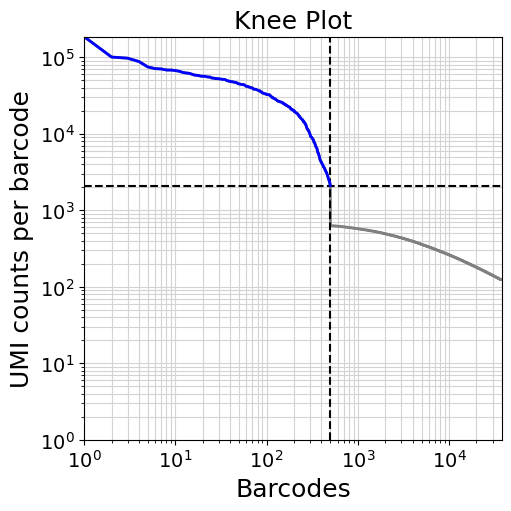

In [ ]:
cs_utils.knee_plot(adata_raw, expected_cells=expected_cells, out_path=os.path.join(out_dir, "knee_plot.png"))

## Cellstraightener Poisson-NB Denoising

In [6]:
import importlib
import cellstraightener.poisson_nb
importlib.reload(cellstraightener.poisson_nb)
from cellstraightener.poisson_nb import denoise_counts_poisson_nb

In [7]:
_ = denoise_counts_poisson_nb(original_matrix, C_out=matrix_cleaned_cs_poisson, empty_threshold=cs_empty_threshold, max_iter=100, verbose=verbose)

01:12:14 - INFO - EM converged at iteration 2 (Δμ=0.00e+00, Δr=0.00e+00)


In [ ]:
%%time
if not os.path.exists(matrix_cleaned_cs_poisson):
    _ = denoise_counts_poisson_nb(original_matrix, C_out=matrix_cleaned_cs_poisson, empty_threshold=cs_empty_threshold, verbose=verbose)

CPU times: user 435 μs, sys: 0 ns, total: 435 μs
Wall time: 360 μs


In [53]:
adata_cellstraightener = ad.read_h5ad(matrix_cleaned_cs_poisson)

## CellBender

In [ ]:
%%time
if not os.path.exists(matrix_cleaned_cellbender):
     !conda run -n cellbender cellbender remove-background \
          --input {original_matrix} \
          --output {matrix_cleaned_cellbender} \
          --expected-cells {expected_cells} \
          --total-droplets-included {cellbender_total_droplets} \
          --epochs {cellbender_epochs} \
          --cpu-threads {threads}

CPU times: user 80 μs, sys: 0 ns, total: 80 μs
Wall time: 95.4 μs


In [55]:
adata_cellbender_with_empty_droplets = anndata_from_h5(matrix_cleaned_cellbender)
adata_cellbender = adata_cellbender_with_empty_droplets[adata_cellbender_with_empty_droplets.obs['cell_probability'] > 0.5]

/home/jrich/miniconda3/envs/cellstraightener/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


In [56]:
print(f"Raw:\n{adata_raw}\n\n")
print(f"CellBender:\n{adata_cellbender}\n\n")
print(f"CellStraightener:\n{adata_cellstraightener}\n\n")

Raw:
AnnData object with n_obs × n_vars = 37760 × 100
    var: 'gene_id', 'genome', 'feature_type'
    uns: 'cellranger_version'


CellBender:
View of AnnData object with n_obs × n_vars = 482 × 100
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency'
    var: 'ambient_expression', 'features_analyzed_inds', 'feature_type', 'genome', 'gene_id', 'cellbender_analyzed'
    uns: 'cell_size_lognormal_std', 'empty_droplet_size_lognormal_loc', 'empty_droplet_size_lognormal_scale', 'swapping_fraction_dist_params', 'estimator', 'fraction_data_used_for_testing', 'learning_curve_learning_rate_epoch', 'learning_curve_learning_rate_value', 'learning_curve_test_elbo', 'learning_curve_test_epoch', 'learning_curve_train_elbo', 'learning_curve_train_epoch', 'target_false_positive_rate'
    obsm: 'gene_expression_encoding'


CellStraightener:
AnnData object with n_obs × n_vars = 500 × 100
    obs: 'barcode'
    var: 'gene_name'




## UpSet plot of retained cells

/home/jrich/miniconda3/envs/cellstraightener/lib/python3.10/site-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)


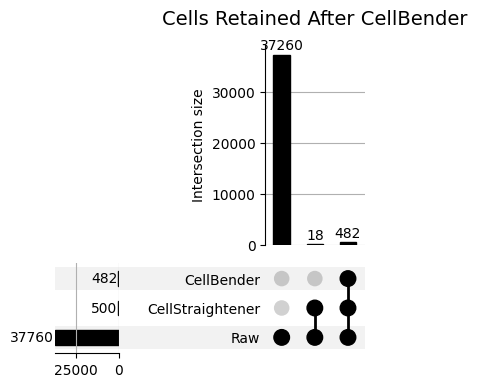

In [57]:
upset_data_dict = {
    "Raw": set(adata_raw.obs_names),
    "CellBender": set(adata_cellbender.obs_names),
    "CellStraightener": set(adata_cellstraightener.obs_names),
}

_ = cs_utils.make_upset_plot(upset_data_dict, title="Cells Retained After CellBender", out_path=os.path.join(out_dir, "cells_retained_upset.png"))

## Heatmap of cell x gene expression differences

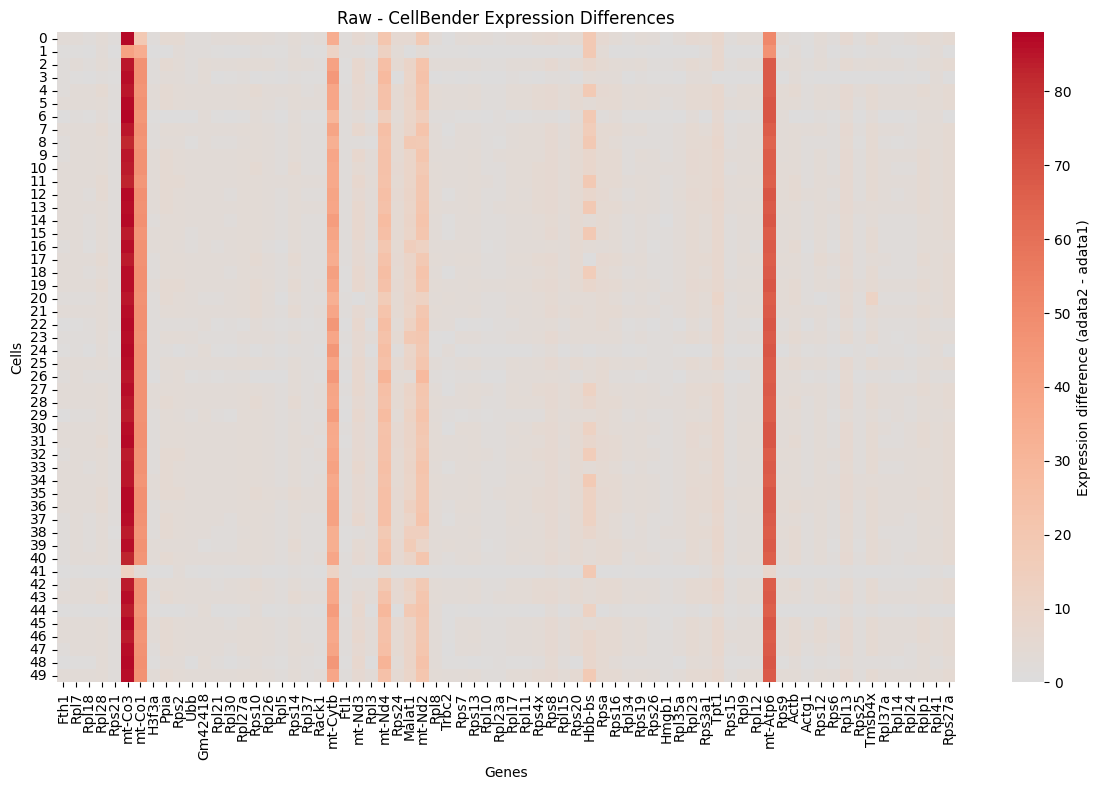

In [58]:
cs_utils.plot_difference_heatmap(adata_raw, adata_cellbender, cell_subset=50, gene_subset=70, show_cell_names=False, title="Raw - CellBender Expression Differences", out_path=os.path.join(out_dir, "raw_vs_cellbender_heatmap.png"))

## Histogram of per-cell Pearson correlations

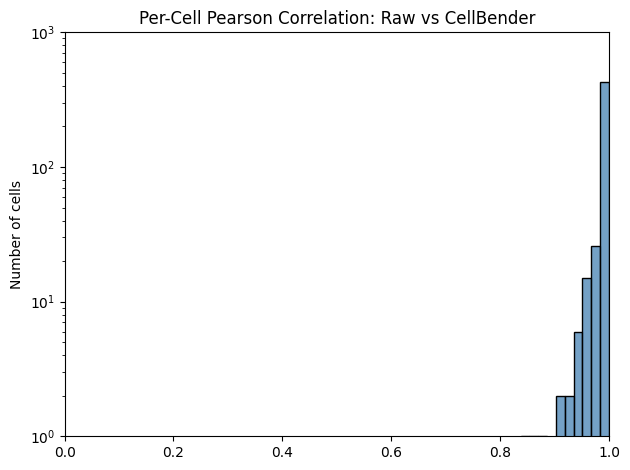

In [59]:
cs_utils.plot_per_cell_correlation(adata_raw, adata_cellbender, title="Per-Cell Pearson Correlation: Raw vs CellBender", out_path=os.path.join(out_dir, "raw_vs_cellbender_per_cell_correlation.png"))

## stop here for tiny dataset

In [60]:
if dataset_name == "tiny_cellbender":
    sys.exit()

SystemExit: 

/home/jrich/miniconda3/envs/cellstraightener/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3587: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


## Alluvial plot of cluster differences

In [ ]:
cs_utils.run_scanpy_preprocessing_and_clustering(adata_raw)
cs_utils.determine_cell_types(adata_raw, method="celltypist", model_pkl=model_pkl)

In [ ]:
# # dummy cell types
# adata_raw.obs["celltype"] = np.random.randint(1, 4, size=len(adata_raw.obs))
# adata_cellbender.obs["celltype"] = np.random.randint(1, 4, size=len(adata_cellbender.obs))
# adata_cellstraightener.obs["celltype"] = np.random.randint(1, 4, size=len(adata_cellstraightener.obs))

col_names = ("raw", "cellbender", "cellstraightener")
df = cs_utils.plot_alluvial(adata_raw, adata_cellbender, adata_cellstraightener, names=col_names, merged_df_csv=os.path.join(out_dir, "alluvial_df.csv"), out_path=os.path.join(out_dir, "cluster_assignment_alluvial.png"), wompwomp_path=wompwomp_path)

conda run -n wompwomp_env /home/jrich/Desktop/wompwomp/exec/wompwomp plot_alluvial --df /home/jrich/Desktop/cellstraightener/notebooks/output/tiny_cellbender/alluvial_df.csv --graphing_columns raw cellbender cellstraightener --coloring_algorithm left -o /home/jrich/Desktop/cellstraightener/notebooks/output/tiny_cellbender/cluster_assignment_alluvial.png


/tmp/ipykernel_2036329/151824394.py:3: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_cellbender.obs["celltype"] = np.random.randint(1, 4, size=len(adata_cellbender.obs))


## Dot plots